# Section H: Health & Physical Fitness

**HSI Weight:** 0.15  
**Effect on Model:** Negative — higher health impairment → lower κ (kill rate)

## Sub-factors
| Variable | Source File | Key Columns |
|---|---|---|
| `obesity_rate` | `data:cdc_places_obesity.csv.csv` | `LocationID`, `MeasureId=='OBESITY'`, `Data_Value` |
| `ambulatory_disability` | `data:acs_disability.csv` | `GEO_ID`, sum of with-difficulty columns / total |
| `nursing_home_density` | `data:cms_nursing_homes_by_tract.csv` | `Latitude`, `Longitude`, `State` — aggregated to county then tract |

## Output
Exports `data/nc_health.csv` with columns: `GEOID`, `obesity_rate`, `ambulatory_disability`, `nursing_home_density`, `score_H`

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Ensure we are running from project root ────────────────────────────────
if os.path.basename(os.getcwd()) == 'Zombie Code':
    os.chdir('..')
print('Working directory:', os.getcwd())

# ── File paths ─────────────────────────────────────────────────────────────
OBESITY_PATH  = 'data/data:cdc_places_obesity.csv.csv'
DISAB_PATH    = 'data/data:acs_disability.csv'
NURSING_PATH  = 'data/data:cms_nursing_homes_by_tract.csv'
OUTPUT_PATH   = 'data/nc_health.csv'

Working directory: /Users/blkcoder/Desktop/Total Zombie Project/You Can Run, You Can Hide/you-can-run-you-can-hide-the-zombie-apocalypse-


## 1. Obesity — CDC PLACES

In [2]:
df_obesity_raw = pd.read_csv(OBESITY_PATH, dtype=str)

df_obesity = (
    df_obesity_raw
    .query("MeasureId == 'OBESITY'")
    [['LocationID', 'Data_Value']]
    .rename(columns={'LocationID': 'GEOID', 'Data_Value': 'obesity_rate'})
    .assign(
        GEOID=lambda d: d['GEOID'].astype(str).str.zfill(11),
        obesity_rate=lambda d: pd.to_numeric(d['obesity_rate'], errors='coerce')
    )
    .dropna(subset=['obesity_rate'])
    .reset_index(drop=True)
)

# Already NC-only but double check
df_obesity = df_obesity[df_obesity['GEOID'].str.startswith('37')]

print(f'Obesity tracts: {len(df_obesity):,}')
print(f'Range: {df_obesity.obesity_rate.min():.1f}% to {df_obesity.obesity_rate.max():.1f}%')
df_obesity.head()

Obesity tracts: 2,647
Range: 20.0% to 59.0%


,GEOID,obesity_rate
0,37025041603,31.6
1,37001020702,39.7
2,37027030600,30.9
3,37027031402,30.2
4,37031970103,35.5


## 2. Ambulatory Disability — ACS B18105

In [3]:
df_disab_raw = pd.read_csv(DISAB_PATH, dtype=str)

# Row 0 = column codes (header), Row 1 = human-readable labels — skip it
# Ambulatory difficulty columns (people WITH difficulty, all age groups):
# Male:   B18105_004E (5-17), B18105_007E (18-34), B18105_010E (35-64),
#         B18105_013E (65-74), B18105_016E (75+)
# Female: B18105_020E (5-17), B18105_023E (18-34), B18105_026E (35-64),
#         B18105_029E (65-74), B18105_032E (75+)

AMB_COLS = [
    'B18105_004E', 'B18105_007E', 'B18105_010E', 'B18105_013E', 'B18105_016E',
    'B18105_020E', 'B18105_023E', 'B18105_026E', 'B18105_029E', 'B18105_032E',
]
TOTAL_COL = 'B18105_001E'

df_disab = df_disab_raw.iloc[1:][['GEO_ID', TOTAL_COL] + AMB_COLS].copy()

df_disab['GEOID'] = df_disab['GEO_ID'].astype(str).str[-11:]
df_disab['total'] = pd.to_numeric(df_disab[TOTAL_COL], errors='coerce')

for col in AMB_COLS:
    df_disab[col] = pd.to_numeric(df_disab[col], errors='coerce').fillna(0)

df_disab['amb_total'] = df_disab[AMB_COLS].sum(axis=1)
df_disab['ambulatory_disability'] = (df_disab['amb_total'] / df_disab['total'] * 100).round(2)

df_disab = (
    df_disab[['GEOID', 'ambulatory_disability']]
    .dropna()
    .reset_index(drop=True)
)
df_disab = df_disab[df_disab['GEOID'].str.startswith('37')]

print(f'Disability tracts: {len(df_disab):,}')
print(f'Range: {df_disab.ambulatory_disability.min():.1f}% to {df_disab.ambulatory_disability.max():.1f}%')
df_disab.head()

Disability tracts: 2,644
Range: 0.0% to 43.6%


,GEOID,ambulatory_disability
0,37001020100,9.75
1,37001020200,6.12
2,37001020301,8.64
3,37001020302,4.26
4,37001020400,8.66


## 3. Nursing Home Density — CMS
CMS file has no GEOID — only lat/lon and state. We count nursing homes per county using nearest-centroid assignment, then broadcast to tracts by county FIPS prefix.

In [4]:
df_nursing_raw = pd.read_csv(NURSING_PATH, dtype=str)

df_nc_nursing = (
    df_nursing_raw
    .query("State == 'NC'")
    [['Provider Name', 'Latitude', 'Longitude']]
    .assign(
        lat=lambda d: pd.to_numeric(d['Latitude'], errors='coerce'),
        lon=lambda d: pd.to_numeric(d['Longitude'], errors='coerce')
    )
    .dropna(subset=['lat', 'lon'])
    .reset_index(drop=True)
)

print(f'NC nursing homes found: {len(df_nc_nursing):,}')
df_nc_nursing.head()

NC nursing homes found: 419


,Provider Name,Latitude,Longitude,lat,lon
0,Autumn Care Of Biscoe,35.3659,-79.79,35.3659,-79.790
1,Hillcrest Convalescent Center,36.0047,-78.918,36.0047,-78.918
2,Cypress Pointe Rehabilitation Center,34.21,-77.926,34.2100,-77.926
3,Silas Creek Rehabilitation Center,36.0751,-80.299,36.0751,-80.299
4,PERSON MEMORIAL HOSPITAL,36.407,-78.985,36.4070,-78.985


In [5]:
# Assign each nursing home to the nearest NC county centroid
NC_COUNTY_CENTROIDS = {
    '37001': (36.04, -79.40), '37003': (35.41, -76.98), '37005': (35.87, -77.79),
    '37007': (35.14, -81.71), '37009': (36.40, -81.23), '37011': (35.67, -78.30),
    '37013': (35.39, -79.69), '37015': (35.99, -77.07), '37017': (35.38, -78.00),
    '37019': (35.66, -81.23), '37021': (35.59, -82.55), '37023': (35.91, -81.54),
    '37025': (35.39, -80.56), '37027': (36.40, -79.71), '37029': (35.72, -78.63),
    '37031': (35.37, -80.07), '37033': (36.10, -79.10), '37035': (35.50, -80.68),
    '37037': (35.17, -79.95), '37039': (36.07, -78.36), '37041': (36.44, -78.76),
    '37043': (35.22, -80.67), '37045': (34.92, -76.27), '37047': (35.59, -77.37),
    '37049': (36.40, -76.98), '37051': (35.05, -78.89), '37053': (35.97, -77.60),
    '37055': (35.79, -82.32), '37057': (35.79, -79.53), '37059': (35.52, -77.07),
    '37061': (35.24, -77.37), '37063': (36.00, -78.90), '37065': (34.96, -77.07),
    '37067': (36.10, -80.24), '37069': (36.40, -79.39), '37071': (36.22, -80.85),
    '37073': (35.83, -76.55), '37075': (36.36, -79.10), '37077': (35.89, -77.02),
    '37079': (36.06, -76.66), '37081': (36.07, -79.79), '37083': (35.47, -77.67),
    '37085': (35.37, -82.94), '37087': (35.99, -82.94), '37089': (35.33, -83.19),
    '37091': (35.66, -79.39), '37093': (35.62, -78.08), '37095': (35.37, -77.08),
    '37097': (35.80, -80.87), '37099': (35.49, -83.54), '37101': (35.59, -79.08),
    '37103': (34.22, -77.86), '37105': (36.11, -78.66), '37107': (36.45, -77.68),
    '37109': (35.44, -83.94), '37111': (35.13, -83.62), '37113': (35.37, -81.25),
    '37115': (35.27, -80.23), '37117': (35.14, -80.52), '37119': (35.25, -80.84),
    '37121': (35.60, -76.76), '37123': (35.14, -77.68), '37125': (35.18, -79.45),
    '37127': (35.62, -80.26), '37129': (35.62, -80.46), '37131': (35.21, -78.63),
    '37133': (35.82, -77.33), '37135': (35.54, -77.37), '37137': (35.84, -76.19),
    '37139': (36.07, -77.37), '37141': (36.45, -78.37), '37143': (35.37, -79.09),
    '37145': (35.40, -77.67), '37147': (35.37, -81.94), '37149': (35.37, -78.62),
    '37151': (36.39, -78.99), '37153': (35.37, -79.69), '37155': (35.27, -79.19),
    '37157': (35.37, -80.46), '37159': (35.37, -79.89), '37161': (35.37, -82.55),
    '37163': (36.45, -80.45), '37165': (36.45, -80.05), '37167': (35.62, -78.64),
    '37169': (35.37, -80.86), '37171': (35.37, -80.26), '37173': (36.39, -80.86),
    '37175': (35.37, -80.66), '37177': (35.37, -77.87), '37179': (35.62, -80.86),
    '37181': (35.82, -78.13), '37183': (35.79, -78.64), '37185': (34.76, -78.11),
    '37187': (35.95, -80.26), '37189': (36.22, -81.69), '37191': (34.74, -76.57),
    '37193': (36.45, -78.13), '37195': (35.42, -83.79), '37197': (35.84, -80.46),
    '37199': (35.37, -76.58), '37201': (36.45, -76.58),
}

def nearest_county(lat, lon):
    best_fips, best_dist = None, float('inf')
    for fips, (clat, clon) in NC_COUNTY_CENTROIDS.items():
        dist = (lat - clat)**2 + (lon - clon)**2
        if dist < best_dist:
            best_dist = dist
            best_fips = fips
    return best_fips

df_nc_nursing['county_fips'] = df_nc_nursing.apply(
    lambda r: nearest_county(r['lat'], r['lon']), axis=1
)

county_nursing_counts = df_nc_nursing.groupby('county_fips').size().rename('nursing_home_density')
print('Nursing homes per county (top 10):')
print(county_nursing_counts.sort_values(ascending=False).head(10))

Nursing homes per county (top 10):
county_fips
37081    20
37119    19
37051    17
37103    17
37063    15
37021    15
37113    14
37161    14
37183    14
37067    13
Name: nursing_home_density, dtype: int64


## 4. Merge All H Sub-factors

In [6]:
df_H = df_obesity.merge(df_disab, on='GEOID', how='outer')

# Broadcast county-level nursing home count to tracts
df_H['county_fips'] = df_H['GEOID'].str[:5]
df_H = df_H.merge(county_nursing_counts, on='county_fips', how='left')
df_H['nursing_home_density'] = df_H['nursing_home_density'].fillna(0)
df_H = df_H.drop(columns=['county_fips'])

print(f'Merged H dataframe: {df_H.shape}')
print(f'Missing values:\n{df_H.isnull().sum()}')
df_H.head()

Merged H dataframe: (2650, 4)
Missing values:
GEOID                    0
obesity_rate             3
ambulatory_disability    6
nursing_home_density     0
dtype: int64


,GEOID,obesity_rate,ambulatory_disability,nursing_home_density
0,37001020100,40.7,9.75,7.0
1,37001020200,49.3,6.12,7.0
2,37001020301,47.4,8.64,7.0
3,37001020302,46.4,4.26,7.0
4,37001020400,48.0,8.66,7.0


## 5. Normalize & Score

In [7]:
def normalize(series: pd.Series) -> pd.Series:
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

for col in ['obesity_rate', 'ambulatory_disability', 'nursing_home_density']:
    df_H[col] = df_H[col].fillna(df_H[col].median())

df_H['obesity_norm']  = normalize(df_H['obesity_rate'])
df_H['disab_norm']    = normalize(df_H['ambulatory_disability'])
df_H['nursing_norm']  = normalize(df_H['nursing_home_density'])

# All factors are NEGATIVE — flip so score_H: 1 = healthiest, 0 = least healthy
df_H['score_H'] = 1 - (
    df_H['obesity_norm']  * (1/3) +
    df_H['disab_norm']    * (1/3) +
    df_H['nursing_norm']  * (1/3)
)

print(f'score_H range: {df_H.score_H.min():.3f} – {df_H.score_H.max():.3f}')
print(f'score_H mean:  {df_H.score_H.mean():.3f}')
df_H[['GEOID','obesity_rate','ambulatory_disability','nursing_home_density','score_H']].head(10)

score_H range: 0.240 – 0.965
score_H mean:  0.671


,GEOID,obesity_rate,ambulatory_disability,nursing_home_density,score_H
0,37001020100,40.7,9.75,7.0,0.631852
1,37001020200,49.3,6.12,7.0,0.586106
2,37001020301,47.4,8.64,7.0,0.583075
3,37001020302,46.4,4.26,7.0,0.625116
4,37001020400,48.0,8.66,7.0,0.577794
5,37001020501,38.3,5.83,7.0,0.682341
6,37001020502,45.5,3.19,7.0,0.640991
7,37001020601,31.0,5.76,7.0,0.745269
8,37001020602,35.3,9.08,7.0,0.683129
9,37001020701,35.3,9.93,7.0,0.676629


## 6. Visualize

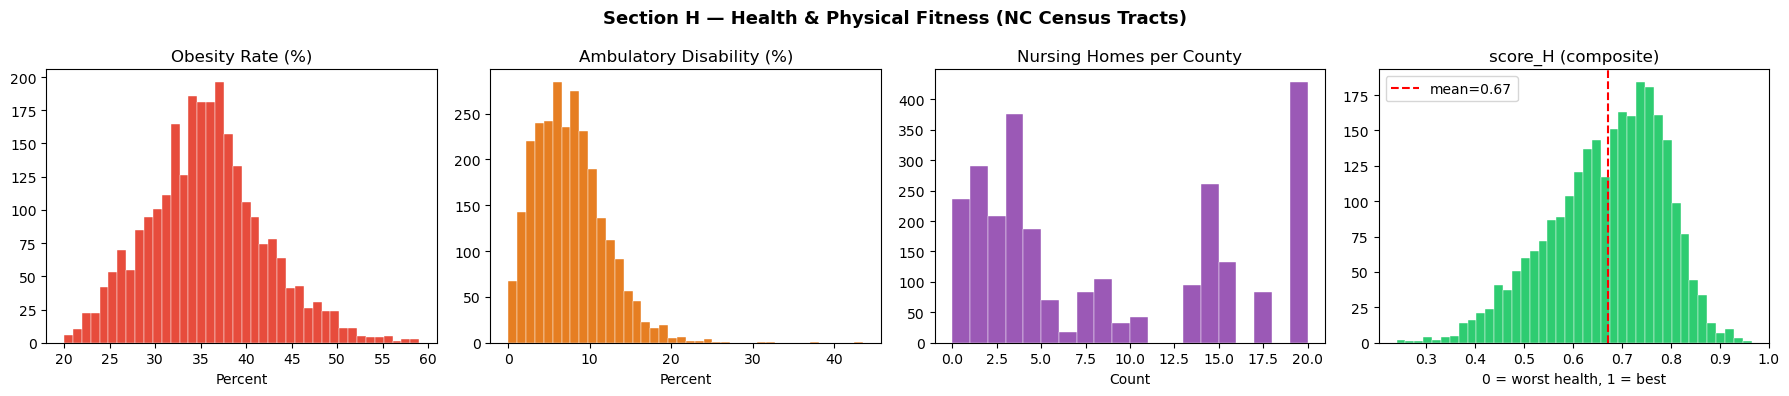


--- KEY FINDINGS ---
Top 5 healthiest tracts:
      GEOID  obesity_rate  ambulatory_disability  score_H
37133001000          24.1                   0.00 0.964957
37135011207          23.1                   2.05 0.941161
37135011602          25.5                   0.06 0.935866
37135011206          25.1                   1.44 0.928732
37135011904          25.1                   1.62 0.927355

Top 5 least healthy tracts:
      GEOID  obesity_rate  ambulatory_disability  score_H
37081013900          57.1                  14.35 0.239838
37067000302          53.4                  31.67 0.255682
37081012706          55.9                  11.68 0.270512
37081011202          53.4                  12.72 0.283927
37051000200          55.1                  15.94 0.294773


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Section H — Health & Physical Fitness (NC Census Tracts)', fontsize=13, fontweight='bold')

axes[0].hist(df_H['obesity_rate'], bins=40, color='#e74c3c', edgecolor='white', linewidth=0.3)
axes[0].set_title('Obesity Rate (%)')
axes[0].set_xlabel('Percent')

axes[1].hist(df_H['ambulatory_disability'], bins=40, color='#e67e22', edgecolor='white', linewidth=0.3)
axes[1].set_title('Ambulatory Disability (%)')
axes[1].set_xlabel('Percent')

axes[2].hist(df_H['nursing_home_density'], bins=20, color='#9b59b6', edgecolor='white', linewidth=0.3)
axes[2].set_title('Nursing Homes per County')
axes[2].set_xlabel('Count')

axes[3].hist(df_H['score_H'], bins=40, color='#2ecc71', edgecolor='white', linewidth=0.3)
axes[3].set_title('score_H (composite)')
axes[3].set_xlabel('0 = worst health, 1 = best')
axes[3].axvline(df_H['score_H'].mean(), color='red', linestyle='--',
                label=f'mean={df_H["score_H"].mean():.2f}')
axes[3].legend()

plt.tight_layout()
plt.savefig('data/fig_H_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- KEY FINDINGS ---')
print('Top 5 healthiest tracts:')
print(df_H.nlargest(5, 'score_H')[['GEOID','obesity_rate','ambulatory_disability','score_H']].to_string(index=False))
print('\nTop 5 least healthy tracts:')
print(df_H.nsmallest(5, 'score_H')[['GEOID','obesity_rate','ambulatory_disability','score_H']].to_string(index=False))

## 7. Export

In [9]:
df_out = df_H[['GEOID','obesity_rate','ambulatory_disability','nursing_home_density','score_H']].copy()
df_out.to_csv(OUTPUT_PATH, index=False)
print(f'Exported {len(df_out):,} tracts to {OUTPUT_PATH}')
df_out.describe()

Exported 2,650 tracts to data/nc_health.csv


,obesity_rate,ambulatory_disability,nursing_home_density,score_H
count,2650.000000,2650.000000,2650.000000,2650.000000
mean,35.712906,7.571253,8.204528,0.671062
std,6.338178,4.335937,7.000381,0.116078
min,20.000000,0.000000,0.000000,0.239838
25%,31.600000,4.332500,2.000000,0.594668
50%,35.500000,7.070000,5.000000,0.686625
75%,39.400000,10.137500,14.000000,0.758058
max,59.000000,43.590000,20.000000,0.964957
